<a href="https://colab.research.google.com/github/Priti-student/cats-vs-dogs-image-classifier/blob/main/Classification_of_cats_vs_dogs_using_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kaggle tensorflow scikit-learn seaborn

In [3]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:06<00:00, 175MB/s] 



In [4]:
!unzip dogsvscats.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/dogs/dog.4419.jpg  
  inflating: train/dogs/dog.442.jpg  
  inflating: train/dogs/dog.4420.jpg  
  inflating: train/dogs/dog.4421.jpg  
  inflating: train/dogs/dog.4422.jpg  
  inflating: train/dogs/dog.4424.jpg  
  inflating: train/dogs/dog.4425.jpg  
  inflating: train/dogs/dog.4426.jpg  
  inflating: train/dogs/dog.4427.jpg  
  inflating: train/dogs/dog.4431.jpg  
  inflating: train/dogs/dog.4433.jpg  
  inflating: train/dogs/dog.4436.jpg  
  inflating: train/dogs/dog.4438.jpg  
  inflating: train/dogs/dog.4439.jpg  
  inflating: train/dogs/dog.444.jpg  
  inflating: train/dogs/dog.4440.jpg  
  inflating: train/dogs/dog.4441.jpg  
  inflating: train/dogs/dog.4442.jpg  
  inflating: train/dogs/dog.4443.jpg  
  inflating: train/dogs/dog.4444.jpg  
  inflating: train/dogs/dog.4445.jpg  
  inflating: train/dogs/dog.4446.jpg  
  inflating: train/dogs/dog.445.jpg  
  inflating: train/dogs/dog.4450.jpg  
  inflating: tra

In [5]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [7]:
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

IMG_SIZE = 224
BATCH_SIZE = 32

data_dir_train = '/content/train'
data_dir_test = '/content/test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir_train,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir_test,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [9]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
base_model.trainable = False

In [11]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation='sigmoid'
)(x)

model = Model(inputs, outputs)

In [12]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor='val_accuracy'
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.9553 - loss: 0.1295 - val_accuracy: 0.9880 - val_loss: 0.0388
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 99ms/step - accuracy: 0.9704 - loss: 0.0791 - val_accuracy: 0.9882 - val_loss: 0.0325
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.9691 - loss: 0.0751 - val_accuracy: 0.9890 - val_loss: 0.0316
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.9720 - loss: 0.0740 - val_accuracy: 0.9890 - val_loss: 0.0288
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.9729 - loss: 0.0698 - val_accuracy: 0.9900 - val_loss: 0.0294
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 116ms/step - accuracy: 0.9732 - loss: 0.0693 - val_accuracy: 0.9896 - val_loss: 0.0289
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.9708 - loss: 0.0743 - val_accuracy: 0.9894 - val_loss: 0.0280
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.9738 - loss: 0.

In [16]:
base_model.trainable = True

In [17]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 121ms/step - accuracy: 0.9427 - loss: 0.1398 - val_accuracy: 0.9874 - val_loss: 0.0331
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.9549 - loss: 0.1096 - val_accuracy: 0.9872 - val_loss: 0.0302
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 117ms/step - accuracy: 0.9607 - loss: 0.0974 - val_accuracy: 0.9884 - val_loss: 0.0290
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 118ms/step - accuracy: 0.9625 - loss: 0.0963 - val_accuracy: 0.9898 - val_loss: 0.0283
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 116ms/step - accuracy: 0.9660 - loss: 0.0844 - val_accuracy: 0.9894 - val_loss: 0.0280


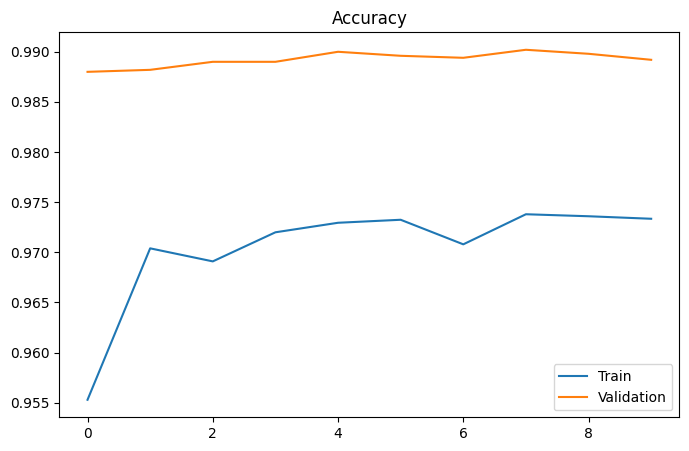

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

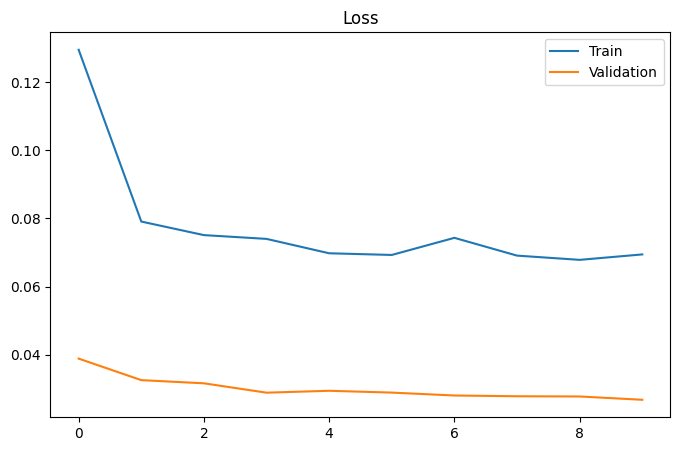

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])
plt.title("Loss")
plt.show()

In [22]:
y_true = []
y_pred = []

In [23]:
for images, labels in val_ds:

    preds = model.predict(images)

    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9

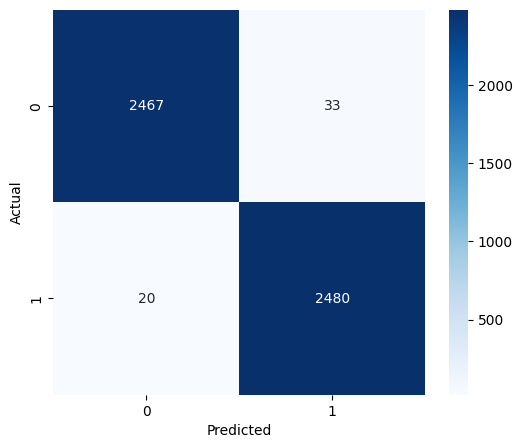

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
class_names = ['cats', 'dogs']

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        cats       0.99      0.99      0.99      2500
        dogs       0.99      0.99      0.99      2500

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



In [27]:
model.save("cats_vs_dogs_model.keras")

### Prediction on a Sample Cat Image

In [28]:
import shutil
import os

# Define paths for sample images
sample_cat_src = '/content/test/cats/cat.10000.jpg'
sample_cat_dest = 'sample_cat.jpg'
sample_dog_src = '/content/test/dogs/dog.10000.jpg'
sample_dog_dest = 'sample_dog.jpg'

# Copy sample cat image
if os.path.exists(sample_cat_src):
    shutil.copy(sample_cat_src, sample_cat_dest)
    print(f"Copied {sample_cat_src} to {sample_cat_dest}")
else:
    print(f"Sample cat image not found at {sample_cat_src}")


Copied /content/test/cats/cat.10000.jpg to sample_cat.jpg


In [29]:
img = tf.keras.utils.load_img(
    "sample_cat.jpg",
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

if prediction > 0.5:
    print("Dog")
else:
    print("Cat")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Cat


### Prediction on a Sample Dog Image

In [35]:
import os
import shutil

# Define the directory where dog images are located
dog_dir = '/content/test/dogs/'

# List all files in the dog directory and find the first .jpg file
dog_images = [f for f in os.listdir(dog_dir) if f.lower().endswith('.jpg')]

if dog_images:
    first_dog_image_filename = dog_images[0]
    sample_dog_src_dynamic = os.path.join(dog_dir, first_dog_image_filename)
    # sample_dog_dest should already be defined from cell fc555529
    shutil.copy(sample_dog_src_dynamic, sample_dog_dest)
    print(f"Copied {sample_dog_src_dynamic} to {sample_dog_dest}")
else:
    print(f"No JPG images found in {dog_dir}")


Copied /content/test/dogs/dog.1259.jpg to sample_dog.jpg


In [36]:
img = tf.keras.utils.load_img(
    "sample_dog.jpg",
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

if prediction > 0.5:
    print("Dog")
else:
    print("Cat")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Dog


In [37]:
img = tf.keras.utils.load_img(
    "sample.jpg",
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

if prediction > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Dog
